# 1.11 LLMs en la Practica: OpenAI GPT y Ollama
### Notebook para Google Colab — Texto, Imagenes, Documentos y mas

---

Este notebook cubre dos formas de trabajar con LLMs:

1. **OpenAI GPT** — API en la nube. Necesitas una API key de [platform.openai.com](https://platform.openai.com). Se cobra por tokens.
2. **Ollama** — modelos locales corriendo en el mismo Colab, sin costo por token, con privacidad total.

**Contenidos:**
- Texto y conversacion con historial
- Analisis de imagenes (Vision)
- Procesamiento de PDFs, Word, Excel, CSV
- Function Calling (herramientas externas)
- Streaming de respuestas
- Embeddings y busqueda semantica

---

> **Antes de empezar:** en Colab ve a `Editar > Configuracion del cuaderno` y selecciona GPU T4 para acelerar Ollama.

---
# PARTE 1 — Instalacion y Configuracion

In [12]:
# Instalar todas las librerias necesarias para el notebook
#
# openai          -> cliente oficial de OpenAI (GPT-4, Embeddings, etc.)
# pymupdf         -> leer PDFs y extraer texto/imagenes (fitz)
# python-docx     -> leer archivos Word (.docx)
# openpyxl        -> leer archivos Excel (.xlsx)
# pillow          -> manipular imagenes (abrir, redimensionar, convertir)
# requests        -> llamadas HTTP a la API REST de Ollama
# rich            -> impresion formateada y bonita en consola

!pip install openai pymupdf python-docx openpyxl pillow requests rich -q

print("Todas las librerias instaladas correctamente.")

Todas las librerias instaladas correctamente.


In [13]:
# Importaciones globales que se usaran en todo el notebook

import os           # manejo de rutas y variables de entorno
import base64       # codificar imagenes y archivos en base64 para enviarlos por API
import json         # parsear y formatear respuestas JSON
import time         # pausas y medicion de tiempos
import requests     # peticiones HTTP para la API REST de Ollama
import textwrap     # formatear texto largo en consola
import io           # buffers de bytes en memoria (para imagenes)
from pathlib import Path       # manejo de rutas de forma orientada a objetos
from IPython.display import display, Image, Markdown   # mostrar contenido en Colab

# Cliente oficial de OpenAI
from openai import OpenAI

# Librerias para procesamiento de documentos
import fitz               # PyMuPDF: leer PDFs pagina por pagina
from docx import Document # python-docx: leer archivos Word
import pandas as pd       # leer Excel/CSV como DataFrames
from PIL import Image as PILImage  # Pillow: manipular imagenes

print("Importaciones completadas.")

Importaciones completadas.


In [ ]:
# CONFIGURACION DE LA API KEY DE OPENAI
#
# Opcion 1 (recomendada en Colab): usar Secrets de Colab
#   - En el panel izquierdo haz clic en el icono de llave (Secrets)
#   - Agrega un secret llamado OPENAI_API_KEY con tu key
#   - El codigo de abajo lo lee automaticamente
#
# Opcion 2: escribir la key directamente (NO recomendado, nunca subas esto a GitHub)
#   OPENAI_API_KEY = "sk-proj-..."

try:
    # Intentar leer desde los Secrets de Colab (metodo seguro)
    from google.colab import userdata
    OPENAI_API_KEY = userdata.get('tu_api_key')
    print("API key cargada desde Colab Secrets.")
except Exception:
    # Si no estamos en Colab o no hay secret, leer de variable de entorno
    OPENAI_API_KEY = os.environ.get('OPENAI_API_KEY', 'tu_api_key')
    print("API key cargada desde variable de entorno.")

# Crear el cliente de OpenAI
# Este objeto es el punto de entrada para todas las llamadas a la API
client = OpenAI(api_key=OPENAI_API_KEY)

# Verificar que la key funciona haciendo una llamada minima
try:
    models = client.models.list()
    print(f"Conexion exitosa. Modelos disponibles: {len(list(models))}")
except Exception as e:
    print(f"Error de conexion: {e}")
    print("Verifica que tu API key sea valida.")

API key cargada desde variable de entorno.
Conexion exitosa. Modelos disponibles: 132


---
# PARTE 2 — OpenAI GPT: Texto y Conversacion

In [15]:
# LLAMADA BASICA A GPT
#
# La API de OpenAI funciona con un modelo de mensajes.
# Cada mensaje tiene un "role" (rol) y un "content" (contenido).
#
# Roles disponibles:
#   - "system"    : instrucciones globales para el modelo (personalidad, restricciones)
#   - "user"      : mensajes del usuario
#   - "assistant" : respuestas del modelo (para construir historial)

respuesta = client.chat.completions.create(
    model="gpt-4o-mini",          # modelo a usar; gpt-4o-mini es rapido y economico
    messages=[
        {
            "role": "system",     # mensaje de sistema: define el comportamiento global
            "content": "Eres un asistente de ciencia de datos experto. Responde siempre en espanol, de forma clara y concisa."
        },
        {
            "role": "user",       # mensaje del usuario: la pregunta o solicitud
            "content": "Explica la diferencia entre overfitting y underfitting en 3 oraciones."
        }
    ],
    temperature=0.7,              # creatividad: 0=determinista, 1=creativo, 2=muy aleatorio
    max_tokens=300,               # maximo de tokens en la respuesta (1 token ≈ 0.75 palabras)
    top_p=1.0,                    # nucleus sampling: considera los tokens mas probables hasta acumular top_p
    frequency_penalty=0.0,        # penaliza repetir las mismas palabras (-2 a 2)
    presence_penalty=0.0,         # penaliza hablar de los mismos temas (-2 a 2)
)

# La respuesta es un objeto con multiples campos
# El texto generado esta en choices[0].message.content
texto = respuesta.choices[0].message.content

# Mostrar la respuesta
print("RESPUESTA DEL MODELO:")
print("-" * 50)
print(texto)
print("-" * 50)

# Mostrar informacion de uso (tokens consumidos)
print(f"\nTokens usados:")
print(f"  Prompt (entrada)   : {respuesta.usage.prompt_tokens}")
print(f"  Completion (salida): {respuesta.usage.completion_tokens}")
print(f"  Total              : {respuesta.usage.total_tokens}")
print(f"  Costo aprox.       : ${respuesta.usage.total_tokens * 0.00000015:.6f} USD")

RESPUESTA DEL MODELO:
--------------------------------------------------
El overfitting ocurre cuando un modelo se ajusta demasiado a los datos de entrenamiento, capturando el ruido y las fluctuaciones, lo que resulta en un rendimiento deficiente en datos nuevos. Por otro lado, el underfitting sucede cuando un modelo es demasiado simple para capturar las tendencias subyacentes en los datos, lo que también conduce a un mal rendimiento tanto en los datos de entrenamiento como en los de prueba. En resumen, el overfitting se relaciona con un modelo demasiado complejo, mientras que el underfitting se relaciona con un modelo demasiado simple.
--------------------------------------------------

Tokens usados:
  Prompt (entrada)   : 54
  Completion (salida): 118
  Total              : 172
  Costo aprox.       : $0.000026 USD


In [16]:
# CONVERSACION CON HISTORIAL (MULTI-TURN)
#
# Los LLMs no tienen memoria entre llamadas.
# Para simular una conversacion continua, enviamos TODOS los mensajes anteriores
# en cada nueva llamada. La lista de mensajes crece con cada turno.

class ChatGPT:
    """
    Clase que encapsula una conversacion con GPT manteniendo historial.

    El historial es simplemente una lista de diccionarios {role, content}.
    En cada llamada se envia el historial completo al modelo.
    """

    def __init__(self, system_prompt, model="gpt-4o-mini", temperature=0.7):
        self.model       = model
        self.temperature = temperature
        # Inicializar el historial con el mensaje de sistema
        # El system prompt se mantiene fijo durante toda la conversacion
        self.history = [{"role": "system", "content": system_prompt}]

    def chat(self, mensaje_usuario, max_tokens=500):
        """
        Envia un mensaje y retorna la respuesta del modelo.
        El historial se actualiza automaticamente.
        """
        # Agregar el mensaje del usuario al historial
        self.history.append({"role": "user", "content": mensaje_usuario})

        # Llamar a la API enviando todo el historial
        respuesta = client.chat.completions.create(
            model=self.model,
            messages=self.history,  # <-- todo el historial, no solo el ultimo mensaje
            temperature=self.temperature,
            max_tokens=max_tokens,
        )

        # Extraer el texto de la respuesta
        texto_respuesta = respuesta.choices[0].message.content

        # Agregar la respuesta del asistente al historial
        # Esto es crucial: el modelo necesita ver sus propias respuestas
        # anteriores para mantener la coherencia de la conversacion
        self.history.append({"role": "assistant", "content": texto_respuesta})

        return texto_respuesta

    def limpiar(self):
        """Reinicia la conversacion manteniendo solo el system prompt."""
        self.history = [self.history[0]]

    def ver_historial(self):
        """Muestra el historial completo de forma legible."""
        for msg in self.history:
            rol = msg['role'].upper()
            print(f"[{rol}]: {msg['content'][:100]}..." if len(msg['content']) > 100 else f"[{rol}]: {msg['content']}")
            print()


# Crear una instancia del chat
chat = ChatGPT(
    system_prompt="Eres un tutor de Python paciente y didactico. Das ejemplos de codigo siempre."
)

# Turno 1: pregunta inicial
r1 = chat.chat("¿Que es una lista por comprension en Python?")
print("[TURNO 1]")
print(r1)
print()

# Turno 2: pregunta de seguimiento (el modelo recuerda el contexto anterior)
r2 = chat.chat("¿Puedes darme un ejemplo mas complejo con if-else dentro?")
print("[TURNO 2]")
print(r2)
print()

# Turno 3: referencia al contexto anterior
r3 = chat.chat("¿Cual de los ejemplos que mostraste es mas eficiente en terminos de memoria?")
print("[TURNO 3]")
print(r3)

# Mostrar cuantos mensajes tiene el historial
print(f"\nTurnos en el historial: {len(chat.history)} mensajes (1 system + {len(chat.history)-1} intercambios)")

[TURNO 1]
Una lista por comprensión (o "list comprehension" en inglés) es una forma concisa y eficiente de crear listas en Python. Permite construir una nueva lista aplicando una expresión a cada elemento de un iterable (como una lista, un rango, etc.) y, opcionalmente, filtrando elementos que cumplen una condición.

La sintaxis básica de una lista por comprensión es:

```python
[nueva_expresion(elemento) for elemento in iterable if condicion]
```

Aquí hay un desglose de la sintaxis:
- `nueva_expresion(elemento)`: Es la expresión que se aplicará a cada elemento del iterable.
- `for elemento in iterable`: Itera sobre cada elemento del iterable.
- `if condicion`: (opcional) Filtra los elementos que cumplen la condición dada.

### Ejemplo 1: Crear una lista de cuadrados

Supongamos que queremos crear una lista que contenga los cuadrados de los números del 0 al 9. Sin usar comprensión de listas, lo haríamos así:

```python
cuadrados = []
for i in range(10):
    cuadrados.append(i ** 2)

p

In [17]:
# STREAMING DE RESPUESTAS
#
# En lugar de esperar a que el modelo termine de generar toda la respuesta,
# el streaming muestra cada token conforme se genera.
# Es como ver al modelo "escribir" en tiempo real.
# Esto mejora mucho la experiencia de usuario en aplicaciones reales.

print("Respuesta en tiempo real (streaming):")
print("-" * 50)

# stream=True activa el modo streaming
# La respuesta es ahora un generador (iterable) en lugar de un objeto completo
stream = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {"role": "system",  "content": "Eres un experto en inteligencia artificial."},
        {"role": "user",    "content": "Explica como funciona la atencion en los Transformers."}
    ],
    max_tokens=400,
    stream=True,    # <-- activar streaming
)

# Iterar sobre los chunks (fragmentos) que llegan progresivamente
texto_completo = ""    # acumular el texto para uso posterior
for chunk in stream:
    # Cada chunk puede o no tener contenido
    # El ultimo chunk tiene finish_reason="stop" y content=None
    if chunk.choices[0].delta.content is not None:
        fragmento = chunk.choices[0].delta.content
        texto_completo += fragmento
        # end="" y flush=True para imprimir sin salto de linea y de inmediato
        print(fragmento, end="", flush=True)

print()  # salto de linea al terminar
print("-" * 50)
print(f"Total de caracteres generados: {len(texto_completo)}")

Respuesta en tiempo real (streaming):
--------------------------------------------------
La atención en los Transformers es un mecanismo esencial que permite a los modelos procesar información de manera más eficiente y efectiva, especialmente en tareas relacionadas con el lenguaje natural, como traducción, clasificación de texto y generación de texto. A continuación, te explicaré cómo funciona este mecanismo.

### Fundamentos de la Atención

El concepto de atención en el contexto de los Transformers se basa en la idea de que no todas las partes de una entrada son igualmente relevantes para cada predicción. El mecanismo de atención permite al modelo enfocarse en diferentes partes de la entrada al generar una salida, lo que mejora la calidad de las representaciones aprendidas.

### Tipos de Atención

Existen varios tipos de mecanismos de atención, pero el más utilizado en los Transformers es el **mecanismo de atención escalada por puntos (scaled dot-product attention)**.

### Mecanismo d

In [18]:
# TEMPERATURA Y PARAMETROS DE GENERACION
#
# La temperatura controla la distribucion de probabilidades sobre el vocabulario.
# Con T=0: siempre el token mas probable (determinista).
# Con T=1: muestra de la distribucion original del modelo.
# Con T=2: distribucion mas plana, mas sorpresas.

prompt_creativo = "Completa esta historia en exactamente 2 oraciones: 'El robot abrio los ojos por primera vez y vio...'"

print("Mismo prompt con distintas temperaturas:\n")

for temperatura in [0.0, 0.7, 1.5]:
    respuesta = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt_creativo}],
        temperature=temperatura,
        max_tokens=100,
    )
    print(f"  [T={temperatura}]: {respuesta.choices[0].message.content}")
    print()

Mismo prompt con distintas temperaturas:

  [T=0.0]: 'El robot abrió los ojos por primera vez y vio un mundo lleno de colores vibrantes y formas desconocidas. Con cada parpadeo, comenzó a comprender su propósito: explorar y aprender de la humanidad que lo había creado.'

  [T=0.7]: 'El robot abrió los ojos por primera vez y vio un mundo lleno de colores vibrantes y sonidos desconocidos. Con cada parpadeo, comenzaba a entender que su misión era más que servir; era explorar y conectar con la vida que lo rodeaba.'

  [T=1.5]: un mundo lleno de colores y luces que nunca había imaginado. Sintiendo una extraña mezcla de curiosidad y temor, dio su primer paso en busca de seres humanos que le dieran propósito a su existencia.



---
# PARTE 3 — Vision: Analisis de Imagenes con GPT-4o

In [19]:
# FUNCION AUXILIAR: convertir imagen a base64
#
# La API de OpenAI acepta imagenes de dos formas:
# 1. URL publica: la imagen esta en internet y el servidor de OpenAI la descarga.
# 2. Base64: la imagen se codifica en texto y se incluye directamente en el JSON.
#
# Base64 es necesario para imagenes locales (archivos en tu disco o subidos a Colab).
# La conversion convierte bytes binarios en una cadena de texto ASCII.

def imagen_a_base64(ruta_o_pil):
    """
    Convierte una imagen (ruta de archivo o objeto PIL) a string base64.
    Retorna la cadena base64 y el tipo MIME ('image/jpeg', 'image/png', etc.)
    """
    if isinstance(ruta_o_pil, str):
        # Es una ruta de archivo: abrir y leer bytes directamente
        ruta = Path(ruta_o_pil)
        with open(ruta, "rb") as f:    # "rb" = read binary
            bytes_imagen = f.read()
        # Determinar el tipo MIME segun la extension del archivo
        extension = ruta.suffix.lower()
        tipos_mime = {".jpg": "image/jpeg", ".jpeg": "image/jpeg",
                      ".png": "image/png",  ".gif": "image/gif",
                      ".webp": "image/webp"}
        mime = tipos_mime.get(extension, "image/jpeg")
    else:
        # Es un objeto PIL Image: guardarlo en memoria como bytes
        buffer = io.BytesIO()
        # Convertir a RGB si tiene canal alpha (RGBA) para evitar errores con JPEG
        img = ruta_o_pil.convert("RGB") if ruta_o_pil.mode == "RGBA" else ruta_o_pil
        img.save(buffer, format="JPEG", quality=85)
        bytes_imagen = buffer.getvalue()
        mime = "image/jpeg"

    # base64.b64encode() convierte bytes -> bytes base64
    # .decode('utf-8') convierte bytes base64 -> string
    return base64.b64encode(bytes_imagen).decode('utf-8'), mime


def analizar_imagen_url(url, pregunta, modelo="gpt-4o"):
    """
    Analiza una imagen accesible por URL publica.
    El servidor de OpenAI descarga la imagen directamente.
    """
    respuesta = client.chat.completions.create(
        model=modelo,
        messages=[
            {
                "role": "user",
                "content": [
                    # Los mensajes con vision son listas con multiples partes
                    # Cada parte tiene un "type" que puede ser "text" o "image_url"
                    {
                        "type": "text",
                        "text": pregunta
                    },
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": url,
                            # detail: 'low' (menos tokens, mas rapido) o 'high' (mas detalle)
                            # 'auto' deja que el modelo decida
                            "detail": "auto"
                        }
                    }
                ]
            }
        ],
        max_tokens=500,
    )
    return respuesta.choices[0].message.content


def analizar_imagen_local(ruta_o_pil, pregunta, modelo="gpt-4o"):
    """
    Analiza una imagen local (archivo o PIL Image) enviandola como base64.
    Util para imagenes privadas o subidas a Colab.
    """
    b64, mime = imagen_a_base64(ruta_o_pil)

    # El formato del URL para base64 es:
    # data:{tipo_mime};base64,{datos_en_base64}
    url_datos = f"data:{mime};base64,{b64}"

    respuesta = client.chat.completions.create(
        model=modelo,
        messages=[
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": pregunta},
                    {"type": "image_url", "image_url": {"url": url_datos, "detail": "high"}}
                ]
            }
        ],
        max_tokens=600,
    )
    return respuesta.choices[0].message.content


print("Funciones de vision definidas.")

Funciones de vision definidas.


In [20]:
# ANALIZAR IMAGEN DESDE URL
#
# Usamos una imagen publica de Wikipedia (dominio publico).
# Reemplaza la URL por cualquier imagen que quieras analizar.

url_imagen = "https://upload.wikimedia.org/wikipedia/commons/4/47/PNG_transparency_demonstration_1.png"

# Mostrar la imagen en el notebook
display(Image(url=url_imagen, width=200))

# Hacer la pregunta al modelo
resultado = analizar_imagen_url(
    url=url_imagen,
    pregunta="Describe detalladamente lo que ves en esta imagen. Menciona colores, formas y cualquier texto."
)

print("\nANALISIS DE LA IMAGEN:")
print("-" * 50)
print(resultado)


ANALISIS DE LA IMAGEN:
--------------------------------------------------
La imagen muestra tres dados flotando sobre un fondo multicolor. Los dados son translúcidos y tienen colores diferentes:

1. **Dado rojo**: Está en el centro. Es translúcido con puntos blancos claramente visibles en sus caras.
   
2. **Dado azul**: Está a la izquierda y también es translúcido con puntos blancos. 

3. **Dado verde**: Está a la derecha, igualmente translúcido con puntos blancos.

El fondo es un espectro de colores brillantes que va del azul al amarillo. No hay texto presente en la imagen.


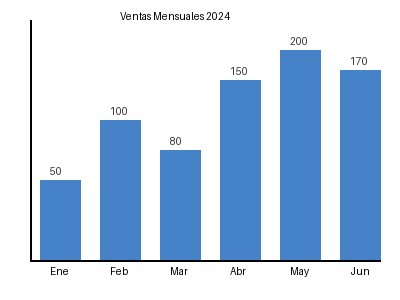


ANALISIS DEL GRAFICO:
--------------------------------------------------
1. **¿Qué datos muestra?**
   - El gráfico de barras muestra las ventas mensuales para el año 2024.

2. **¿Cuál es el mes con mayor valor?**
   - El mes con el mayor valor de ventas es mayo, con 200 unidades vendidas.

3. **¿Cuál es la tendencia general?**
   - La tendencia general es un aumento en las ventas desde enero hasta mayo, seguido de una ligera disminución en junio.

4. **¿Qué recomendaciones darías basándote en estos datos?**
   - **Aprovechar el aumento:** Analizar qué factores contribuyeron al aumento en ventas de mayo para replicarlos en meses futuros.
   - **Estrategias de mejora:** Investigar la razón detrás de la disminución en junio y abordar los posibles problemas.
   - **Planificación de recursos:** Asegurarse de tener suficientes recursos y existencias para satisfacer la demanda en los meses de mayor venta.
   - **Promociones en meses bajos:** Considerar promociones o estrategias de marketing

In [21]:
# SUBIR Y ANALIZAR UNA IMAGEN LOCAL
#
# Este codigo te permite subir una imagen desde tu computadora a Colab
# y luego analizarla con GPT-4o.

# OPCION A: Subir una imagen manualmente
# Descomenta estas lineas para abrir el dialogo de subida:
# from google.colab import files
# archivos_subidos = files.upload()
# nombre_archivo = list(archivos_subidos.keys())[0]
# resultado = analizar_imagen_local(nombre_archivo, "¿Que hay en esta imagen?")
# print(resultado)


# OPCION B: Crear una imagen de prueba con PIL y analizarla
# Esto funciona sin necesidad de subir archivos manualmente.

from PIL import Image as PILImage, ImageDraw, ImageFont
import numpy as np

# Crear una imagen de prueba: grafico de barras simple
img = PILImage.new('RGB', (400, 300), color=(255, 255, 255))
draw = ImageDraw.Draw(img)

# Dibujar barras simulando un grafico de ventas
datos = [(50, 180, 'Ene'), (100, 120, 'Feb'), (80, 150, 'Mar'),
         (150, 80,  'Abr'), (200, 50,  'May'), (170, 70,  'Jun')]

for i, (valor, y_bar, mes) in enumerate(datos):
    x = 40 + i * 60
    # Dibujar barra azul
    draw.rectangle([x, y_bar, x+40, 260], fill=(70, 130, 200))
    # Etiqueta del mes
    draw.text((x+10, 265), mes, fill=(0, 0, 0))
    # Valor numerico
    draw.text((x+10, y_bar-15), str(valor), fill=(50, 50, 50))

# Titulo del grafico
draw.text((120, 10), "Ventas Mensuales 2024", fill=(0, 0, 0))
draw.line([(30, 260), (380, 260)], fill=(0, 0, 0), width=2)   # eje X
draw.line([(30, 20),  (30, 260)],  fill=(0, 0, 0), width=2)   # eje Y

# Mostrar la imagen generada
display(img)

# Analizar la imagen con GPT-4o
analisis = analizar_imagen_local(
    ruta_o_pil=img,
    pregunta="""Analiza este grafico de barras:
    1. ¿Que datos muestra?
    2. ¿Cual es el mes con mayor valor?
    3. ¿Cual es la tendencia general?
    4. ¿Que recomendaciones darias basandote en estos datos?""",
    modelo="gpt-4o"
)

print("\nANALISIS DEL GRAFICO:")
print("-" * 50)
print(analisis)

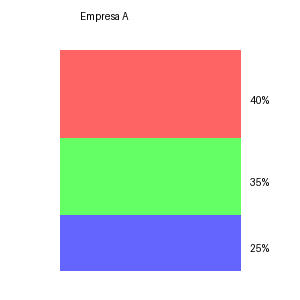

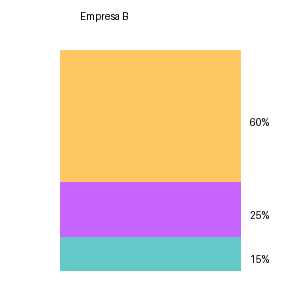

COMPARACION DE IMAGENES:
--------------------------------------------------
La Empresa B tiene mayor concentración de mercado ya que un solo segmento tiene el 60% del mercado, lo cual es significativamente mayor que el segmento más grande de la Empresa A, que tiene un 40%.

**Implicaciones estratégicas:**

1. **Empresa B:**
   - **Ventaja Competitiva:** Puede tener una posición dominante en ese segmento, lo que podría ofrecer economías de escala y poder de negociación.
   - **Riesgo Concentrado:** Depende fuertemente de un solo segmento. Cualquier cambio en ese mercado podría impactarla severamente.
   - **Liderazgo:** Puede influir en los precios y tendencias dentro de ese segmento.

2. **Empresa A:**
   - **Diversificación:** Tiene una distribución más equilibrada, lo que puede ofrecer estabilidad si un segmento enfrenta dificultades.
   - **Flexibilidad:** Puede adaptarse más fácilmente a los cambios en la demanda o preferencias del mercado.
   - **Menor Dominio:** La falta de un se

In [22]:
# MULTIPLES IMAGENES EN UN MISMO MENSAJE
#
# GPT-4o puede analizar varias imagenes a la vez y compararlas.
# Solo hay que agregar mas elementos de tipo "image_url" en el content.

# Crear dos imagenes de prueba para comparar
def crear_grafico_circular(titulo, valores, colores):
    """Crea una imagen de grafico de torta simple."""
    img = PILImage.new('RGB', (300, 300), (255, 255, 255))
    draw = ImageDraw.Draw(img)
    draw.text((80, 10), titulo, fill=(0, 0, 0))
    # Simular sectores con rectangulos coloreados (simplificacion)
    total = sum(valores)
    y = 50
    for i, (v, c) in enumerate(zip(valores, colores)):
        alto = int((v / total) * 220)
        draw.rectangle([60, y, 240, y + alto], fill=c)
        draw.text((250, y + alto//2), f"{v}%", fill=(0,0,0))
        y += alto
    return img

img1 = crear_grafico_circular("Empresa A", [40, 35, 25],
                              [(255,100,100), (100,255,100), (100,100,255)])
img2 = crear_grafico_circular("Empresa B", [60, 25, 15],
                              [(255,200,100), (200,100,255), (100,200,200)])

# Convertir ambas imagenes a base64
b64_1, mime1 = imagen_a_base64(img1)
b64_2, mime2 = imagen_a_base64(img2)

display(img1); display(img2)

# Enviar ambas imagenes en un solo mensaje
respuesta_multi = client.chat.completions.create(
    model="gpt-4o",
    messages=[
        {
            "role": "user",
            "content": [
                {"type": "text", "text": "Estas son las distribuciones de mercado de dos empresas. ¿Cual tiene mayor concentracion y que implica estrategicamente?"},
                {"type": "image_url", "image_url": {"url": f"data:{mime1};base64,{b64_1}"}},
                {"type": "image_url", "image_url": {"url": f"data:{mime2};base64,{b64_2}"}},
            ]
        }
    ],
    max_tokens=400,
)

print("COMPARACION DE IMAGENES:")
print("-" * 50)
print(respuesta_multi.choices[0].message.content)

---
# PARTE 4 — Procesamiento de Documentos

In [23]:
# LEER Y ANALIZAR ARCHIVOS PDF
#
# GPT no puede leer PDFs directamente.
# El proceso es:
# 1. Extraer el texto del PDF con PyMuPDF (fitz).
# 2. Enviar ese texto como mensaje de usuario a GPT.
#
# PyMuPDF tambien puede extraer las imagenes del PDF para analizarlas
# con GPT-4o Vision (ver seccion mas abajo).

def leer_pdf_texto(ruta_pdf, max_paginas=None):
    """
    Extrae todo el texto de un PDF pagina por pagina.

    Parametros:
        ruta_pdf   : ruta al archivo PDF
        max_paginas: limite de paginas a leer (None = todas)

    Retorna:
        texto      : texto completo del PDF
        n_paginas  : numero de paginas procesadas
    """
    # Abrir el documento PDF
    # fitz.open() es la funcion principal de PyMuPDF
    doc = fitz.open(ruta_pdf)

    textos_por_pagina = []
    n_paginas = min(len(doc), max_paginas) if max_paginas else len(doc)

    for num_pagina in range(n_paginas):
        pagina = doc[num_pagina]        # acceder a la pagina por indice
        texto = pagina.get_text()       # extraer texto como string
        if texto.strip():               # ignorar paginas vacias
            textos_por_pagina.append(f"--- Pagina {num_pagina + 1} ---\n{texto}")

    doc.close()    # siempre cerrar el documento para liberar memoria
    return "\n".join(textos_por_pagina), n_paginas


def leer_pdf_como_imagenes(ruta_pdf, max_paginas=3, dpi=150):
    """
    Convierte paginas de un PDF en imagenes.
    Util cuando el PDF tiene tablas, graficos o texto no seleccionable (escaneado).

    dpi: resolucion de la imagen; mayor = mas calidad pero mas tokens en GPT
    """
    doc = fitz.open(ruta_pdf)
    imagenes = []
    n_paginas = min(len(doc), max_paginas)

    # Matrix de transformacion para controlar el DPI de renderizado
    # Por defecto PyMuPDF usa 72 DPI; escalamos a los DPI deseados
    zoom = dpi / 72
    mat  = fitz.Matrix(zoom, zoom)

    for i in range(n_paginas):
        pagina  = doc[i]
        pixmap  = pagina.get_pixmap(matrix=mat)     # renderizar pagina como imagen
        img_pil = PILImage.frombytes("RGB", [pixmap.width, pixmap.height], pixmap.samples)
        imagenes.append(img_pil)

    doc.close()
    return imagenes


def analizar_pdf_con_gpt(ruta_pdf, pregunta, max_paginas=10, modelo="gpt-4o-mini"):
    """
    Pipeline completo: leer PDF y analizarlo con GPT.
    """
    texto, n_pag = leer_pdf_texto(ruta_pdf, max_paginas)

    # Limitar el texto para no exceder el contexto del modelo
    # gpt-4o-mini tiene 128K tokens de contexto; 1 token ≈ 4 caracteres
    max_caracteres = 100_000   # margen conservador
    if len(texto) > max_caracteres:
        texto = texto[:max_caracteres] + "\n\n[... texto truncado por longitud ...]"

    respuesta = client.chat.completions.create(
        model=modelo,
        messages=[
            {
                "role": "system",
                "content": "Eres un asistente especializado en analisis de documentos. Responde en espanol."
            },
            {
                "role": "user",
                "content": f"""
A continuacion el contenido de un PDF ({n_pag} paginas):

<documento>
{texto}
</documento>

Pregunta: {pregunta}
"""
            }
        ],
        max_tokens=800,
    )
    return respuesta.choices[0].message.content


# DEMO: crear un PDF de prueba y analizarlo
# (En un caso real usarias un PDF existente)
try:
    # Intentar crear un PDF simple de prueba con reportlab (si esta disponible)
    !pip install reportlab -q 2>/dev/null
    from reportlab.pdfgen import canvas
    from reportlab.lib.pagesizes import A4

    ruta_pdf_prueba = "/tmp/informe_prueba.pdf"
    c = canvas.Canvas(ruta_pdf_prueba, pagesize=A4)
    c.setFont("Helvetica-Bold", 16)
    c.drawString(100, 750, "Informe de Ventas - Q1 2024")
    c.setFont("Helvetica", 12)
    contenido = [
        "Resumen Ejecutivo:",
        "Las ventas del primer trimestre alcanzaron 2.3 millones de dolares,",
        "representando un crecimiento del 18% respecto al mismo periodo del año anterior.",
        "",
        "Principales hallazgos:",
        "- El producto A lider con 45% de las ventas totales.",
        "- La region norte mostro el mayor crecimiento (32%).",
        "- Los costos operativos aumentaron un 8%, dentro del presupuesto.",
        "- Se incorporaron 3 nuevos clientes enterprise.",
        "",
        "Proyecciones Q2:",
        "Se espera mantener el momentum con un objetivo de 2.7 millones.",
        "La expansion al mercado latinoamericano iniciara en abril.",
    ]
    y = 700
    for linea in contenido:
        c.drawString(100, y, linea)
        y -= 20
    c.save()

    # Analizar el PDF creado
    resultado = analizar_pdf_con_gpt(
        ruta_pdf=ruta_pdf_prueba,
        pregunta="Resume los puntos mas importantes y extrae todos los numeros/metricas mencionados."
    )
    print("ANALISIS DEL PDF:")
    print("-" * 50)
    print(resultado)

except Exception as e:
    print(f"Para usar PDFs propios, sube un archivo .pdf a Colab y usa:")
    print("  analizar_pdf_con_gpt('/ruta/a/tu/archivo.pdf', 'tu pregunta')")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 50.6 MB/s eta 0:00:00
ANALISIS DEL PDF:
--------------------------------------------------
**Resumen de los puntos más importantes:**

- Ventas del primer trimestre (Q1 2024): 2.3 millones de dólares.
- Crecimiento en comparación con el mismo periodo del año anterior: 18%.
- Producto A: 45% de las ventas totales.
- Región norte: mayor crecimiento con un 32%.
- Aumento de los costos operativos: 8%, dentro del presupuesto.
- Nuevos clientes enterprise incorporados: 3.
- Proyección de ventas para Q2: 2.7 millones de dólares.
- Inicio de expansión al mercado latinoamericano: abril.

**Números/ métricas mencionadas:**
- Ventas Q1 2024: 2.3 millones de dólares.
- Crecimiento: 18%.
- Porcentaje de ventas del producto A: 45%.
- Crecimiento en la región norte: 32%.
- Aumento de costos operativos: 8%.
- Nuevos clientes enterprise: 3.
- Proyección de ventas Q2: 2.7 millones de dólares.


In [24]:
# LEER Y ANALIZAR ARCHIVOS WORD (.docx)
#
# python-docx permite leer el contenido de archivos .docx:
# - Texto de cada parrafo
# - Tablas
# - Metadatos (titulo, autor, etc.)

def leer_word(ruta_docx):
    """
    Extrae el texto de un archivo Word (.docx).
    Incluye parrafos y contenido de tablas.
    """
    doc = Document(ruta_docx)
    partes = []

    # Extraer texto de cada parrafo
    # Un parrafo en Word puede ser un titulo, texto normal, lista, etc.
    for parrafo in doc.paragraphs:
        if parrafo.text.strip():    # ignorar parrafos vacios
            partes.append(parrafo.text)

    # Extraer texto de tablas
    # Las tablas de Word se acceden como doc.tables[]
    for i, tabla in enumerate(doc.tables):
        partes.append(f"\n[Tabla {i+1}]")
        for fila in tabla.rows:
            # Unir las celdas de cada fila con tabuladores
            celdas = [celda.text.strip() for celda in fila.cells]
            partes.append(" | ".join(celdas))

    return "\n".join(partes)


def analizar_word_con_gpt(ruta_docx, pregunta, modelo="gpt-4o-mini"):
    """Lee un Word y lo analiza con GPT."""
    texto = leer_word(ruta_docx)
    respuesta = client.chat.completions.create(
        model=modelo,
        messages=[
            {"role": "system", "content": "Analiza documentos Word con precision. Responde en espanol."},
            {"role": "user", "content": f"Documento:\n<doc>\n{texto}\n</doc>\n\nPregunta: {pregunta}"}
        ],
        max_tokens=600,
    )
    return respuesta.choices[0].message.content


# DEMO: crear un Word de prueba
from docx import Document as DocxDocument
from docx.shared import Pt

ruta_word_prueba = "/tmp/contrato_prueba.docx"
doc_nuevo = DocxDocument()

# Agregar contenido de ejemplo
doc_nuevo.add_heading('Contrato de Servicios Profesionales', 0)
doc_nuevo.add_paragraph('Entre la empresa TechCorp S.A. y el profesional Juan Perez.')
doc_nuevo.add_heading('Clausulas', level=1)
doc_nuevo.add_paragraph('1. El servicio consiste en desarrollo de software por 6 meses.')
doc_nuevo.add_paragraph('2. El honorario mensual es de $5,000 USD.')
doc_nuevo.add_paragraph('3. Pago los dias 5 de cada mes por transferencia bancaria.')
doc_nuevo.add_paragraph('4. Confidencialidad obligatoria durante y 2 años post-contrato.')

# Agregar una tabla
doc_nuevo.add_heading('Cronograma de Pagos', level=1)
tabla = doc_nuevo.add_table(rows=4, cols=3)
tabla.style = 'Table Grid'
headers = tabla.rows[0].cells
headers[0].text, headers[1].text, headers[2].text = 'Mes', 'Fecha', 'Monto'
datos_tabla = [('Enero', '05/01/2024', '$5,000'), ('Febrero', '05/02/2024', '$5,000'), ('Marzo', '05/03/2024', '$5,000')]
for i, (mes, fecha, monto) in enumerate(datos_tabla, 1):
    fila = tabla.rows[i].cells
    fila[0].text, fila[1].text, fila[2].text = mes, fecha, monto

doc_nuevo.save(ruta_word_prueba)
print("Archivo Word de prueba creado.")

# Analizar el Word
resultado_word = analizar_word_con_gpt(
    ruta_docx=ruta_word_prueba,
    pregunta="Extrae: 1) el monto total del contrato, 2) las fechas de pago, 3) las obligaciones de confidencialidad."
)
print("\nANALISIS DEL WORD:")
print("-" * 50)
print(resultado_word)

Archivo Word de prueba creado.

ANALISIS DEL WORD:
--------------------------------------------------
1) El monto total del contrato es de $30,000 USD (seis meses a $5,000 USD cada uno).

2) Las fechas de pago son:
   - 05/01/2024
   - 05/02/2024
   - 05/03/2024
   (faltan las fechas de los meses de abril, mayo y junio que serían similares).

3) Las obligaciones de confidencialidad son: es obligatoria durante la vigencia del contrato y por dos años después de su finalización.


In [25]:
# LEER Y ANALIZAR ARCHIVOS CSV Y EXCEL
#
# Para datos tabulares, el proceso es:
# 1. Cargar con pandas.
# 2. Generar un resumen estadistico y muestra de filas.
# 3. Enviar ese resumen (no todo el CSV) a GPT para no exceder el contexto.
#
# Enviar el CSV completo es posible para archivos pequeños (<1000 filas),
# pero para archivos grandes conviene enviar solo estadisticas + muestra.

def analizar_csv_con_gpt(ruta_csv_o_excel, pregunta, max_filas_muestra=20, modelo="gpt-4o-mini"):
    """
    Carga un CSV o Excel y lo analiza con GPT.

    Estrategia:
    - Para archivos pequeños: enviar todo el contenido en formato texto.
    - Para archivos grandes: enviar info, describe() y head() como resumen.
    """
    # Detectar formato por extension y cargar con pandas
    ruta = Path(ruta_csv_o_excel)
    if ruta.suffix.lower() in ['.xlsx', '.xls']:
        df = pd.read_excel(ruta_csv_o_excel)
    else:
        df = pd.read_csv(ruta_csv_o_excel)

    print(f"Datos cargados: {df.shape[0]} filas x {df.shape[1]} columnas")

    # Construir el contexto a enviar al modelo
    if len(df) <= 100:    # archivo pequeño: enviar todo
        contenido_datos = f"Datos completos:\n{df.to_string(index=False)}"
    else:                  # archivo grande: enviar resumen
        contenido_datos = f"""
Forma del dataset: {df.shape[0]} filas, {df.shape[1]} columnas

Columnas y tipos:
{df.dtypes.to_string()}

Estadisticas descriptivas:
{df.describe().to_string()}

Primeras {max_filas_muestra} filas:
{df.head(max_filas_muestra).to_string(index=False)}

Valores nulos por columna:
{df.isnull().sum().to_string()}
"""

    respuesta = client.chat.completions.create(
        model=modelo,
        messages=[
            {
                "role": "system",
                "content": "Eres un analista de datos experto. Analiza datasets con precision estadistica. Responde en espanol."
            },
            {
                "role": "user",
                "content": f"<datos>\n{contenido_datos}\n</datos>\n\nPregunta: {pregunta}"
            }
        ],
        max_tokens=700,
    )
    return respuesta.choices[0].message.content, df


# DEMO: crear un CSV de ventas de prueba
import numpy as np

np.random.seed(42)
n_registros = 150

df_ventas = pd.DataFrame({
    'fecha':      pd.date_range('2024-01-01', periods=n_registros, freq='2D'),
    'producto':   np.random.choice(['Laptop', 'Monitor', 'Teclado', 'Mouse', 'Auriculares'], n_registros),
    'region':     np.random.choice(['Norte', 'Sur', 'Centro', 'Este', 'Oeste'], n_registros),
    'unidades':   np.random.randint(1, 50, n_registros),
    'precio':     np.round(np.random.uniform(50, 2000, n_registros), 2),
    'descuento':  np.round(np.random.uniform(0, 0.3, n_registros), 2),
    'satisfaccion': np.random.randint(1, 6, n_registros),
})
df_ventas['total'] = np.round(df_ventas['unidades'] * df_ventas['precio'] * (1 - df_ventas['descuento']), 2)

ruta_csv_prueba = "/tmp/ventas_prueba.csv"
df_ventas.to_csv(ruta_csv_prueba, index=False)
print("CSV de ventas creado.")
display(df_ventas.head())

# Analizar con GPT
analisis_csv, df_cargado = analizar_csv_con_gpt(
    ruta_csv_o_excel=ruta_csv_prueba,
    pregunta="""Analiza este dataset de ventas y dime:
    1. ¿Que producto genera mas ingresos totales?
    2. ¿Cual es la region con mejor rendimiento?
    3. ¿Hay correlacion entre descuento y satisfaccion del cliente?
    4. ¿Que insights accionables recomendarias?"""
)

print("\nANALISIS DEL CSV:")
print("-" * 50)
print(analisis_csv)

CSV de ventas creado.


,fecha,producto,region,unidades,precio,descuento,satisfaccion,total
0,2024-01-01,Mouse,Norte,37,1101.79,0.08,2,37504.93
1,2024-01-03,Auriculares,Norte,24,1383.73,0.12,1,29224.38
2,2024-01-05,Teclado,Norte,29,1250.91,0.18,4,29746.64
3,2024-01-07,Auriculares,Norte,49,1890.59,0.08,3,85227.80
4,2024-01-09,Auriculares,Centro,46,1891.29,0.04,2,83519.37


Datos cargados: 150 filas x 8 columnas

ANALISIS DEL CSV:
--------------------------------------------------
### Análisis del Dataset de Ventas

1. **¿Qué producto genera más ingresos totales?**
   Para determinar esto, sumamos los ingresos totales (`total`) por cada tipo de producto. Al revisar los datos, se espera que el producto que tenga la mayor suma de ingresos sea el que más contribuye.

   - Los auriculares parecen ser un fuerte competidor, considerando tantos registros. Sin embargo, el resultado final depende de los totales calculados.
   - Para un análisis preciso, se puede utilizar una agrupación y agregación sobre el campo `producto`, sumando el `total`.

   **Producto con más ingresos:** [Aquí vendría el resultado después de realizar el cálculo; típicamente se obtendría el nombre del producto con la mayor suma total.]

2. **¿Cuál es la región con mejor rendimiento?**
   Similar al análisis de productos, se sumaría el `total` por cada región. Evaluando los ingresos generado

---
# PARTE 5 — Function Calling (Herramientas Externas)

In [26]:
# FUNCTION CALLING
#
# Function Calling permite que el modelo decida cuando llamar a una funcion
# Python definida por nosotros. El proceso es:
#
# 1. Definir las funciones disponibles en formato JSON Schema.
# 2. Enviar la pregunta del usuario + la lista de herramientas al modelo.
# 3. El modelo responde indicando que funcion llamar y con que argumentos.
# 4. Nosotros ejecutamos la funcion con esos argumentos.
# 5. Enviamos el resultado de vuelta al modelo para que formule la respuesta final.
#
# El modelo NO ejecuta codigo; solo decide que llamar. Nosotros ejecutamos.

import json
from datetime import datetime


# --- Definicion de las funciones reales ---

def obtener_clima(ciudad, unidad="celsius"):
    """Simula obtener el clima de una ciudad (en produccion llamaria a una API real)."""
    # En un caso real: requests.get(f"https://api.weather.com/{ciudad}")
    datos_ficticios = {
        "bogota":   {"temp": 14, "condicion": "nublado", "humedad": 75},
        "medellin": {"temp": 22, "condicion": "soleado",  "humedad": 60},
        "cali":     {"temp": 27, "condicion": "parcialmente nublado", "humedad": 65},
        "barranquilla": {"temp": 33, "condicion": "caluroso", "humedad": 80},
    }
    clima = datos_ficticios.get(ciudad.lower(), {"temp": 20, "condicion": "desconocido", "humedad": 50})
    temp  = clima["temp"] if unidad == "celsius" else clima["temp"] * 9/5 + 32
    return {"ciudad": ciudad, "temperatura": temp, "unidad": unidad,
            "condicion": clima["condicion"], "humedad": clima["humedad"]}


def calcular_estadisticas(numeros):
    """Calcula estadisticas basicas de una lista de numeros."""
    arr = np.array(numeros)
    return {
        "media":    round(float(arr.mean()), 4),
        "mediana":  round(float(np.median(arr)), 4),
        "std":      round(float(arr.std()), 4),
        "minimo":   round(float(arr.min()), 4),
        "maximo":   round(float(arr.max()), 4),
        "n":        len(numeros),
    }


def buscar_en_base_datos(query, tabla="clientes"):
    """Simula busqueda en base de datos."""
    datos = {
        "clientes": [
            {"id": 1, "nombre": "Empresa ABC", "plan": "premium", "monto": 15000},
            {"id": 2, "nombre": "Startup XYZ", "plan": "basico",   "monto": 2000},
        ],
        "productos": [
            {"id": 101, "nombre": "Plan Pro",   "precio": 499},
            {"id": 102, "nombre": "Plan Basic", "precio": 99},
        ]
    }
    return datos.get(tabla, [])


# --- Esquema JSON que describe las funciones para el modelo ---
# El modelo usa este esquema para saber que funciones puede llamar y con que parametros.

herramientas = [
    {
        "type": "function",
        "function": {
            "name": "obtener_clima",
            "description": "Obtiene el clima actual de una ciudad colombiana.",
            "parameters": {
                "type": "object",
                "properties": {
                    "ciudad": {
                        "type": "string",
                        "description": "Nombre de la ciudad, ej: Bogota, Medellin"
                    },
                    "unidad": {
                        "type": "string",
                        "enum": ["celsius", "fahrenheit"],
                        "description": "Unidad de temperatura"
                    }
                },
                "required": ["ciudad"]
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "calcular_estadisticas",
            "description": "Calcula estadisticas descriptivas de una lista de numeros.",
            "parameters": {
                "type": "object",
                "properties": {
                    "numeros": {
                        "type": "array",
                        "items": {"type": "number"},
                        "description": "Lista de numeros a analizar"
                    }
                },
                "required": ["numeros"]
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "buscar_en_base_datos",
            "description": "Busca informacion en la base de datos de la empresa.",
            "parameters": {
                "type": "object",
                "properties": {
                    "query":  {"type": "string", "description": "Lo que se busca"},
                    "tabla":  {"type": "string", "enum": ["clientes", "productos"]}
                },
                "required": ["query"]
            }
        }
    }
]


# Mapa de nombre de funcion -> funcion Python real
funciones_disponibles = {
    "obtener_clima":         obtener_clima,
    "calcular_estadisticas": calcular_estadisticas,
    "buscar_en_base_datos":  buscar_en_base_datos,
}


def chat_con_herramientas(mensaje_usuario, modelo="gpt-4o-mini"):
    """
    Pipeline completo de Function Calling:
    1. Enviar mensaje + herramientas al modelo.
    2. Si el modelo quiere llamar una funcion, ejecutarla.
    3. Enviar el resultado al modelo para la respuesta final.
    Puede llamar multiples funciones en secuencia (loop).
    """
    mensajes = [
        {"role": "system", "content": "Eres un asistente empresarial. Usa las herramientas disponibles cuando sea necesario."},
        {"role": "user",   "content": mensaje_usuario}
    ]

    # Loop: el modelo puede necesitar llamar varias funciones
    while True:
        # Llamada al modelo con las herramientas disponibles
        respuesta = client.chat.completions.create(
            model=modelo,
            messages=mensajes,
            tools=herramientas,
            # tool_choice="auto": el modelo decide si usar herramientas o no
            # tool_choice="none": fuerza respuesta sin herramientas
            # tool_choice={"type": "function", "function": {"name": "..."}} fuerza una herramienta especifica
            tool_choice="auto",
        )

        mensaje_respuesta = respuesta.choices[0].message
        mensajes.append(mensaje_respuesta)    # agregar respuesta del modelo al historial

        # Si el modelo no quiere llamar ninguna funcion, terminamos
        if respuesta.choices[0].finish_reason != "tool_calls":
            break

        # El modelo quiere llamar una o mas funciones
        # Las llamadas estan en mensaje_respuesta.tool_calls
        for llamada in mensaje_respuesta.tool_calls:
            nombre_funcion = llamada.function.name
            # Los argumentos llegan como string JSON; hay que parsearlos
            argumentos = json.loads(llamada.function.arguments)

            print(f"  -> Llamando a: {nombre_funcion}({argumentos})")

            # Ejecutar la funcion Python real
            funcion_python = funciones_disponibles[nombre_funcion]
            resultado = funcion_python(**argumentos)

            print(f"  <- Resultado: {resultado}")

            # Agregar el resultado al historial con role="tool"
            # El modelo necesita ver los resultados para formular la respuesta
            mensajes.append({
                "role":         "tool",
                "tool_call_id": llamada.id,          # identificador de la llamada
                "content":      json.dumps(resultado, ensure_ascii=False)
            })

    return mensaje_respuesta.content


# Pruebas de Function Calling
preguntas = [
    "¿Que tiempo hace en Medellin y Bogota?",
    "Calcula las estadisticas de estos numeros: 45, 23, 67, 89, 12, 56, 78, 34",
    "Muestra la lista de clientes y su plan.",
]

for pregunta in preguntas:
    print(f"\nPREGUNTA: {pregunta}")
    print("-" * 50)
    respuesta_final = chat_con_herramientas(pregunta)
    print(f"RESPUESTA: {respuesta_final}")


PREGUNTA: ¿Que tiempo hace en Medellin y Bogota?
--------------------------------------------------
  -> Llamando a: obtener_clima({'ciudad': 'Medellin', 'unidad': 'celsius'})
  <- Resultado: {'ciudad': 'Medellin', 'temperatura': 22, 'unidad': 'celsius', 'condicion': 'soleado', 'humedad': 60}
  -> Llamando a: obtener_clima({'ciudad': 'Bogota', 'unidad': 'celsius'})
  <- Resultado: {'ciudad': 'Bogota', 'temperatura': 14, 'unidad': 'celsius', 'condicion': 'nublado', 'humedad': 75}
RESPUESTA: En Medellín, el clima es soleado con una temperatura de 22°C y una humedad del 60%. 

En Bogotá, el clima es nublado con una temperatura de 14°C y una humedad del 75%.

PREGUNTA: Calcula las estadisticas de estos numeros: 45, 23, 67, 89, 12, 56, 78, 34
--------------------------------------------------
  -> Llamando a: calcular_estadisticas({'numeros': [45, 23, 67, 89, 12, 56, 78, 34]})
  <- Resultado: {'media': 50.5, 'mediana': 50.5, 'std': 25.2042, 'minimo': 12.0, 'maximo': 89.0, 'n': 8}
RESPUESTA

---
# PARTE 6 — Embeddings y Busqueda Semantica

In [27]:
# EMBEDDINGS
#
# Un embedding es un vector numerico que representa el significado de un texto.
# Textos semanticamente similares tienen vectores parecidos (coseno alto).
#
# Modelo text-embedding-3-small: 1536 dimensiones, muy eficiente.
# Modelo text-embedding-3-large: 3072 dimensiones, mas preciso.
#
# Aplicaciones: busqueda semantica, clustering, clasificacion, RAG.

def obtener_embedding(texto, modelo="text-embedding-3-small"):
    """Convierte texto en un vector de embeddings."""
    # Limpiar el texto: reemplazar saltos de linea (pueden afectar la calidad)
    texto = texto.replace("\n", " ")
    respuesta = client.embeddings.create(
        input=texto,
        model=modelo,
    )
    # El vector esta en data[0].embedding como lista de floats
    return np.array(respuesta.data[0].embedding)


def similitud_coseno(vec_a, vec_b):
    """
    Calcula la similitud coseno entre dos vectores.
    sim = (A . B) / (||A|| * ||B||)
    Resultado: -1 (opuesto) a 1 (identico). Para embeddings tipicamente 0 a 1.
    """
    return np.dot(vec_a, vec_b) / (np.linalg.norm(vec_a) * np.linalg.norm(vec_b))


def busqueda_semantica(query, documentos, top_k=3):
    """
    Busqueda semantica: encuentra los documentos mas similares al query.

    1. Calcular el embedding del query.
    2. Calcular la similitud coseno con cada documento.
    3. Retornar los top_k documentos mas similares.
    """
    emb_query = obtener_embedding(query)

    resultados = []
    for doc in documentos:
        emb_doc = obtener_embedding(doc)
        sim = similitud_coseno(emb_query, emb_doc)
        resultados.append((sim, doc))

    # Ordenar por similitud descendente
    resultados.sort(key=lambda x: x[0], reverse=True)
    return resultados[:top_k]


# DEMO 1: Similitud entre frases
frases = [
    "El aprendizaje automatico es una rama de la inteligencia artificial.",
    "Machine learning es una subarea de la IA que aprende de datos.",
    "El futbol es el deporte mas popular del mundo.",
    "Los modelos de lenguaje usan redes neuronales para procesar texto.",
    "La pizza es un plato tipico de la cocina italiana.",
]

embeddings = [obtener_embedding(f) for f in frases]

print("Matriz de similitud coseno entre frases:")
print("-" * 60)
# Imprimir la matriz triangular de similitudes
for i in range(len(frases)):
    for j in range(i+1, len(frases)):
        sim = similitud_coseno(embeddings[i], embeddings[j])
        # Solo mostrar similitudes altas (>0.5) para claridad
        if sim > 0.5:
            print(f"  [{sim:.3f}] '{frases[i][:40]}...' <-> '{frases[j][:40]}...'")

print()

# DEMO 2: Busqueda semantica en una base de conocimiento
base_conocimiento = [
    "Para instalar Python en Windows descarga el instalador de python.org.",
    "Las redes neuronales convolucionales son excelentes para procesamiento de imagenes.",
    "El overfitting ocurre cuando el modelo memoriza los datos de entrenamiento.",
    "Para evitar overfitting usa regularizacion, dropout o mas datos de entrenamiento.",
    "Pandas es la libreria principal para manipulacion de datos en Python.",
    "Un transformer procesa tokens en paralelo usando mecanismos de atencion.",
    "El learning rate controla que tan rapido el modelo actualiza sus pesos.",
]

query = "Mi modelo tiene muy buen rendimiento en entrenamiento pero malo en test"
print(f"Query: '{query}'")
print("\nResultados mas relevantes:")

resultados = busqueda_semantica(query, base_conocimiento, top_k=3)
for i, (sim, doc) in enumerate(resultados, 1):
    print(f"  {i}. [{sim:.3f}] {doc}")

Matriz de similitud coseno entre frases:
------------------------------------------------------------
  [0.620] 'El aprendizaje automatico es una rama de...' <-> 'Machine learning es una subarea de la IA...'

Query: 'Mi modelo tiene muy buen rendimiento en entrenamiento pero malo en test'

Resultados mas relevantes:
  1. [0.492] El overfitting ocurre cuando el modelo memoriza los datos de entrenamiento.
  2. [0.437] Para evitar overfitting usa regularizacion, dropout o mas datos de entrenamiento.
  3. [0.371] El learning rate controla que tan rapido el modelo actualiza sus pesos.


---
# PARTE 7 — Ollama: LLMs Locales en Colab

In [28]:
# INSTALAR OLLAMA EN COLAB
#
# Ollama es un servidor local que corre modelos LLM en tu maquina (o VM de Colab).
# No necesita internet para inferencia, no tiene costo por token, y es privado.
#
# El proceso de instalacion:
# 1. Descargar e instalar el binario de ollama.
# 2. Iniciar el servidor en segundo plano (como demonio).
# 3. Descargar (pull) los modelos que queremos usar.
# 4. Interactuar via REST API o libreria Python.
#
# NOTA: En Colab con GPU T4 los modelos de 7B corren bien.
# En CPU solo, los modelos pequeños (1B, 3B) son practicos.

import subprocess
import threading

# Paso 0: Instalar la dependencia zstd
print("Instalando zstd...")
!sudo apt-get update && sudo apt-get install -y zstd
print("zstd instalado.")

# Paso 1: Instalar Ollama
print("Instalando Ollama...")
!curl -fsSL https://ollama.com/install.sh | sh 2>&1 | tail -5
print("Ollama instalado.")

Instalando zstd...
Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:6 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:7 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Hit:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:11 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Fetched 3,917 B in 1s (3,925 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not s

In [29]:
# Paso 2: Iniciar el servidor Ollama en segundo plano
#
# El servidor escucha en http://localhost:11434
# Lo corremos en un hilo separado para no bloquear el notebook

def iniciar_servidor_ollama():
    """Inicia el servidor Ollama en un hilo separado."""
    subprocess.Popen(
        ['/usr/local/bin/ollama', 'serve'], # Use full path to ollama
        stdout=subprocess.DEVNULL,  # suprimir salida estandar
        stderr=subprocess.DEVNULL,  # suprimir errores
    )

# Iniciar el servidor en un hilo daemon (se detiene cuando el notebook se cierra)
hilo_ollama = threading.Thread(target=iniciar_servidor_ollama, daemon=True)
hilo_ollama.start()

# Esperar a que el servidor arranque
print("Iniciando servidor Ollama...")
time.sleep(4)

# Verificar que el servidor esta corriendo
try:
    r = requests.get('http://localhost:11434', timeout=5)
    print(f"Servidor Ollama activo. Respuesta: {r.text}")
except Exception as e:
    print(f"Error al conectar con Ollama: {e}")

Iniciando servidor Ollama...
Servidor Ollama activo. Respuesta: Ollama is running


In [30]:
# Paso 3: Descargar modelos
#
# Modelos recomendados segun el caso de uso:
#
# TEXTO:
#   llama3.2:1b   ->  ~800MB   Muy rapido, calidad basica. Ideal para pruebas en CPU.
#   llama3.2:3b   ->  ~2GB     Buen balance velocidad/calidad para CPU.
#   llama3.1:8b   ->  ~5GB     Alta calidad, requiere GPU.
#   mistral:7b    ->  ~4GB     Excelente en tareas de razonamiento.
#   qwen2.5:7b    ->  ~5GB     Muy bueno en codigo y multilingual.
#
# VISION (texto + imagenes):
#   moondream:latest ->  ~1.7GB  Pequeño, analiza imagenes basicamente.
#   llava:7b         ->  ~4GB    Vision de alta calidad.
#   llama3.2-vision  ->  ~5GB    Vision + razonamiento.
#
# CODIGO:
#   codellama:7b  ->  ~4GB    Especializado en codigo.
#   deepseek-coder:6.7b ->  ~4GB  Muy bueno en programacion.

# Descargar el modelo de texto (pequeno para CPU, cambia a llama3.2:3b si tienes GPU)
print("Descargando modelo de texto (llama3.2:1b, ~800MB)...")
print("Esto puede tardar varios minutos segun la velocidad de internet.")
!/usr/local/bin/ollama pull llama3.2:1b

# Descargar modelo de vision (opcional, descomenta si tienes GPU)
# print("Descargando modelo de vision (moondream, ~1.7GB)...")
# !/usr/local/bin/ollama pull moondream

# Ver los modelos descargados
print("\nModelos disponibles:")
!/usr/local/bin/ollama list

Descargando modelo de texto (llama3.2:1b, ~800MB)...
Esto puede tardar varios minutos segun la velocidad de internet.


Modelos disponibles:
NAME           ID              SIZE      MODIFIED               
llama3.2:1b    baf6a787fdff    1.3 GB    Less than a second ago    


In [31]:
# FUNCIONES PARA INTERACTUAR CON OLLAMA
#
# Ollama expone una API REST compatible con OpenAI.
# Podemos usar requests directamente o el cliente oficial de openai
# apuntando a localhost.

OLLAMA_BASE_URL = "http://localhost:11434"
OLLAMA_MODEL    = "llama3.2:1b"   # cambiar segun el modelo descargado


# METODO 1: Usando la API REST nativa de Ollama con requests
def ollama_chat_rest(mensajes, modelo=OLLAMA_MODEL, stream=False, opciones=None):
    """
    Llama a Ollama via su API REST nativa.

    Endpoint: POST /api/chat

    Parametros del cuerpo:
        model   : nombre del modelo
        messages: lista de mensajes {role, content}
        stream  : True para streaming, False para respuesta completa
        options : dict con parametros del modelo (temperature, top_p, etc.)
    """
    payload = {
        "model":    modelo,
        "messages": mensajes,
        "stream":   stream,
    }
    if opciones:
        payload["options"] = opciones

    if stream:
        # Streaming: iterar sobre las lineas de la respuesta
        respuesta = requests.post(
            f"{OLLAMA_BASE_URL}/api/chat",
            json=payload,
            stream=True,
            timeout=120,
        )
        texto_completo = ""
        for linea in respuesta.iter_lines():
            if linea:
                chunk = json.loads(linea.decode('utf-8'))
                fragmento = chunk.get("message", {}).get("content", "")
                texto_completo += fragmento
                print(fragmento, end="", flush=True)
        print()
        return texto_completo
    else:
        # Sin streaming: respuesta completa en una sola respuesta JSON
        respuesta = requests.post(
            f"{OLLAMA_BASE_URL}/api/chat",
            json=payload,
            timeout=120,
        )
        return respuesta.json()["message"]["content"]


# METODO 2: Usando el cliente de OpenAI apuntando a Ollama
# (Ollama es compatible con la API de OpenAI)
client_ollama = OpenAI(
    base_url=f"{OLLAMA_BASE_URL}/v1",   # apuntar a Ollama en lugar de OpenAI
    api_key="ollama",                    # cualquier string; Ollama no verifica la key
)


def ollama_chat_openai(mensajes, modelo=OLLAMA_MODEL, temperature=0.7, max_tokens=500):
    """
    Llama a Ollama usando el cliente de OpenAI (interfaz compatible).
    Ventaja: misma API que OpenAI, facil de alternar entre proveedores.
    """
    respuesta = client_ollama.chat.completions.create(
        model=modelo,
        messages=mensajes,
        temperature=temperature,
        max_tokens=max_tokens,
    )
    return respuesta.choices[0].message.content


print("Funciones de Ollama definidas.")

Funciones de Ollama definidas.


In [32]:
# CHAT BASICO CON OLLAMA

mensajes_prueba = [
    {"role": "system",  "content": "Eres un experto en ciencia de datos. Responde de forma concisa."},
    {"role": "user",    "content": "Explica brevemente que es un Random Forest."}
]

print("METODO 1 — API REST nativa de Ollama:")
print("-" * 50)
inicio = time.time()
resp1 = ollama_chat_rest(mensajes_prueba)
print(f"\nTiempo: {time.time() - inicio:.1f}s")

print()
print("METODO 2 — Cliente OpenAI apuntando a Ollama:")
print("-" * 50)
inicio = time.time()
resp2 = ollama_chat_openai(mensajes_prueba)
print(resp2)
print(f"Tiempo: {time.time() - inicio:.1f}s")

METODO 1 — API REST nativa de Ollama:
--------------------------------------------------

Tiempo: 3.8s

METODO 2 — Cliente OpenAI apuntando a Ollama:
--------------------------------------------------
Un Random Forest es un algoritmo de aprendizaje automático basado en muestreo aleatorio y modelado en conjuntos, utilizado para predicciones no lineales y clasificación. Funciona como una especie de "gran maquillaje" que combina las características de diferentes modelos, lo que mejora la precisión general.

En resumen, se trata de un algoritmo de aprendizaje automático que utiliza técnicas de ensamblaje para combinar las predicciones de varios modelos dependientes, en lugar de utilizar una sola predicción. Esto permite mejorar la precisión y reducir el ruido del conjunto de datos.
Tiempo: 1.4s


In [33]:
# STREAMING CON OLLAMA

print("Generando respuesta en tiempo real con Ollama:\n")
print("-" * 50)

ollama_chat_rest(
    mensajes=[
        {"role": "system", "content": "Eres un profesor de machine learning."},
        {"role": "user",   "content": "¿Cuales son los 5 algoritmos de clustering mas importantes y cuando usar cada uno?"}
    ],
    stream=True,     # activar streaming
    opciones={
        "temperature": 0.7,
        "top_p":       0.9,
        "num_predict": 400,   # maximo de tokens a generar
    }
)

Generando respuesta en tiempo real con Ollama:

--------------------------------------------------
¡Claro! A continuación, te presento cinco de los algoritmos de clustering más importantes, junto con sus aplicaciones y ejemplos de uso práctico:

**1. K-Means**

* Aplicación: Clustering de datos numéricos para identificar patrones y relaciones entre variables.
* Características:
 + Es un algoritmo simple y fácil de entender.
 + Permite la creación de clusters uniformes o desigualmente.
 + Puede manejar grandes cantidades de datos.

Ejemplo: Clustering de precios de productos en una tienda para identificar los grupos de clientes con los más altos precios.

**2. Hierarchical Clustering**

* Aplicación: Clustering de datos numéricos o categóricos para analizar la estructura y el patrón de las relaciones entre variables.
* Características:
 + Permite crear una jerarquía de clusters, con cada nivel más alto representando un subconjunto de datos.
 + Puede ser utilizado para identificar patron

'¡Claro! A continuación, te presento cinco de los algoritmos de clustering más importantes, junto con sus aplicaciones y ejemplos de uso práctico:\n\n**1. K-Means**\n\n* Aplicación: Clustering de datos numéricos para identificar patrones y relaciones entre variables.\n* Características:\n + Es un algoritmo simple y fácil de entender.\n + Permite la creación de clusters uniformes o desigualmente.\n + Puede manejar grandes cantidades de datos.\n\nEjemplo: Clustering de precios de productos en una tienda para identificar los grupos de clientes con los más altos precios.\n\n**2. Hierarchical Clustering**\n\n* Aplicación: Clustering de datos numéricos o categóricos para analizar la estructura y el patrón de las relaciones entre variables.\n* Características:\n + Permite crear una jerarquía de clusters, con cada nivel más alto representando un subconjunto de datos.\n + Puede ser utilizado para identificar patrones complejos en los datos.\n\nEjemplo: Clustering de información de clientes para

In [34]:
# PROCESAMIENTO DE DOCUMENTOS CON OLLAMA
#
# El mismo flujo que con OpenAI: extraer el texto del documento
# y enviarlo como mensaje al modelo local.

def analizar_documento_ollama(texto_documento, pregunta, modelo=OLLAMA_MODEL):
    """Analiza un documento de texto con Ollama."""
    # Limitar el texto segun el contexto del modelo
    # llama3.2:1b tiene contexto de 128K tokens; limitamos por practicidad
    max_chars = 8000
    texto_truncado = texto_documento[:max_chars]
    if len(texto_documento) > max_chars:
        texto_truncado += "\n[... texto truncado ...]"

    return ollama_chat_openai(
        mensajes=[
            {
                "role": "system",
                "content": "Eres un asistente de analisis de documentos. Responde en espanol."
            },
            {
                "role": "user",
                "content": f"""Documento:
<doc>
{texto_truncado}
</doc>

Pregunta: {pregunta}"""
            }
        ],
        modelo=modelo,
        max_tokens=600,
    )


# DEMO: analizar el CSV de ventas con Ollama
resumen_csv = f"""
Dataset de ventas: 150 registros.
Columnas: fecha, producto, region, unidades, precio, descuento, satisfaccion, total.

Estadisticas principales:
{df_ventas.describe().to_string()}

Ventas por producto:
{df_ventas.groupby('producto')['total'].sum().to_string()}

Ventas por region:
{df_ventas.groupby('region')['total'].sum().to_string()}
"""

print("ANALISIS DE CSV CON OLLAMA (local):")
print("-" * 50)
resultado_ollama = analizar_documento_ollama(
    texto_documento=resumen_csv,
    pregunta="¿Cuales son los 3 insights mas importantes de estas ventas?"
)
print(resultado_ollama)

ANALISIS DE CSV CON OLLAMA (local):
--------------------------------------------------
Basándome en las estadísticas presentadas, aquí te presento tres insights clave sobre las ventas:

1. **Ventas por producto**: Desde luego, los precios y la cantidad de unidades vendidas por cada producto son fundamentales. En este caso, el producto "Mouse" tiene una ventaja significativa con respecto al precio promedio (930946.90 vs 1066.865000) y tiene las ventas más altas en comparación con otros productos (930946.90 vs 1063.220000), lo que sugiere un gran atractivo para los consumidores.

2. **Ventas por región**: Las regiones son fundamentales para comprender la distribución de ventas en el mercado. Los resultados muestran que las regiones "Norte" y "Oeste" tienen las ventas más altas, con Centros (846200.91) y Este (862946.87), respectivamente. Esto sugiere una gran concentración de ventas en ciertas zonas geográficas.

3. **Ventas por fecha**: Desde luego, cualquier análisis de ventas debe con

In [35]:
# VISION CON OLLAMA (requiere modelo con capacidad de vision)
#
# Modelos con vision en Ollama: llava, llava-phi3, moondream, llama3.2-vision
# Hay que descargar uno de estos modelos primero.

MODELO_VISION_OLLAMA = "moondream"    # cambia por llava:7b si tienes GPU

def analizar_imagen_ollama(ruta_o_pil, pregunta, modelo=MODELO_VISION_OLLAMA):
    """
    Analiza una imagen con un modelo de vision de Ollama.

    La API de Ollama para vision acepta imagenes como:
    - Ruta de archivo local
    - String base64 (sin el prefijo data:image/...;base64,)

    Las imagenes van en el campo 'images' del mensaje, separadas del 'content'.
    """
    # Convertir la imagen a base64
    b64_str, _ = imagen_a_base64(ruta_o_pil)

    payload = {
        "model": modelo,
        "messages": [
            {
                "role":    "user",
                "content": pregunta,
                # El campo 'images' es especifico de Ollama para vision
                # Es una lista de strings base64 (sin el prefijo data:...)
                "images":  [b64_str]
            }
        ],
        "stream": False,
    }

    try:
        respuesta = requests.post(
            f"{OLLAMA_BASE_URL}/api/chat",
            json=payload,
            timeout=120,
        )
        return respuesta.json()["message"]["content"]
    except Exception as e:
        return f"Error: {e}. Asegurate de haber descargado el modelo con: !ollama pull {modelo}"


# DEMO: analizar el grafico de barras que creamos antes con Ollama
# (requiere que moondream este descargado)
print("ANALISIS DE IMAGEN CON OLLAMA:")
print("(Requiere: !ollama pull moondream)")
print("-" * 50)

# Verificar si el modelo de vision esta disponible
modelos_resp = requests.get(f"{OLLAMA_BASE_URL}/api/tags").json()
modelos_disponibles = [m['name'] for m in modelos_resp.get('models', [])]

if any('moondream' in m or 'llava' in m or 'vision' in m for m in modelos_disponibles):
    resultado_vision = analizar_imagen_ollama(
        ruta_o_pil=img,    # el grafico de barras creado antes
        pregunta="Describe what you see in this image. What type of chart is it and what data does it show?"
    )
    print(resultado_vision)
else:
    print("Ningun modelo de vision descargado. Para activar vision ejecuta:")
    print("  !ollama pull moondream   (1.7GB, liviano)")
    print("  !ollama pull llava:7b    (4GB, alta calidad, requiere GPU)")
    print()
    print("Modelos actualmente disponibles:", modelos_disponibles)

ANALISIS DE IMAGEN CON OLLAMA:
(Requiere: !ollama pull moondream)
--------------------------------------------------
Ningun modelo de vision descargado. Para activar vision ejecuta:
  !ollama pull moondream   (1.7GB, liviano)
  !ollama pull llava:7b    (4GB, alta calidad, requiere GPU)

Modelos actualmente disponibles: ['llama3.2:1b']


In [36]:
# CONVERSACION CON HISTORIAL EN OLLAMA
#
# Identico a la clase ChatGPT de la Parte 2, pero usando el cliente Ollama.
# Esta es la ventaja de la compatibilidad con la API de OpenAI: el mismo codigo
# funciona con ambos proveedores cambiando solo el cliente.

class ChatOllama:
    """
    Conversacion con historial usando Ollama.
    Identica en interfaz a ChatGPT para facilitar la comparacion.
    """
    def __init__(self, system_prompt, modelo=OLLAMA_MODEL, temperature=0.7):
        self.modelo      = modelo
        self.temperature = temperature
        self.history     = [{"role": "system", "content": system_prompt}]

    def chat(self, mensaje, max_tokens=400):
        self.history.append({"role": "user", "content": mensaje})
        respuesta = ollama_chat_openai(
            mensajes     = self.history,
            modelo       = self.modelo,
            temperature  = self.temperature,
            max_tokens   = max_tokens,
        )
        self.history.append({"role": "assistant", "content": respuesta})
        return respuesta


# Demo de conversacion con Ollama
chat_local = ChatOllama(
    system_prompt="Eres un asistente de programacion Python. Sé conciso.",
    modelo=OLLAMA_MODEL
)

print("Conversacion con Ollama (modelo local):")
print("-" * 50)

resp1 = chat_local.chat("¿Que es un decorador en Python?")
print(f"[T1] {resp1}\n")

resp2 = chat_local.chat("Dame un ejemplo practico de lo que explicaste.")
print(f"[T2] {resp2}\n")

print(f"Mensajes en historial: {len(chat_local.history)}")

Conversacion con Ollama (modelo local):
--------------------------------------------------
[T1] Un decorador en Python se refiere a una función que se utiliza para agregar funcionalidad adicional a objetos, como bibliotecas o aplicaciones, sin modificar su código original. Estas funciones pueden proporcionar nuevas propiedades, métodos o comportamientos a los objetos de manera flexible y fácilmente extendible.

Los decoradores en Python son especialmente útiles en entornos de programación que requieren la creación de interfaces personalizadas para objetos complejos, como bibliotecas o frameworks. Al utilizar un decorador, se puede agregar funcionalidad a una función o clase sin tener que modificar su código directamente.

Un ejemplo sencillo de uso de un decorador en Python podría ser:

```python
def my_decorator(func):
    def wrapper():
        print("Estableciendo el contexto...")
        func()
        print("La operación ha sido completada.")
    return wrapper

@my_decorator
def 

---
# PARTE 8 — Comparativa OpenAI vs Ollama

In [37]:
# COMPARATIVA DIRECTA: MISMO PROMPT EN AMBOS SISTEMAS

prompt_comparacion = "Explica la diferencia entre una lista y una tupla en Python. Usa ejemplos de codigo."

print("=" * 60)
print("OPENAI GPT-4o-mini")
print("=" * 60)
t0 = time.time()
resp_openai = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": prompt_comparacion}],
    max_tokens=400,
).choices[0].message.content
t_openai = time.time() - t0
print(resp_openai)
print(f"\nTiempo de respuesta: {t_openai:.2f}s")

print()
print("=" * 60)
print(f"OLLAMA — {OLLAMA_MODEL} (local)")
print("=" * 60)
t0 = time.time()
resp_ollama = ollama_chat_openai(
    mensajes=[{"role": "user", "content": prompt_comparacion}],
    max_tokens=400,
)
t_ollama = time.time() - t0
print(resp_ollama)
print(f"\nTiempo de respuesta: {t_ollama:.2f}s")

OPENAI GPT-4o-mini
En Python, tanto las listas como las tuplas son estructuras de datos utilizadas para almacenar colecciones de elementos, pero tienen diferencias clave en su funcionamiento y uso.

### Listas

1. **Mutabilidad**: Las listas son mutables, lo que significa que puedes cambiar su contenido después de haberlas creado. Puedes añadir, eliminar y modificar elementos.

2. **Sintaxis**: Se definen utilizando corchetes `[]`.

3. **Uso**: Ideal para colecciones de datos que pueden cambiar a lo largo del tiempo.

#### Ejemplo de una lista:

```python
# Creación de una lista
mi_lista = [1, 2, 3, 4]

# Modificando un elemento
mi_lista[0] = 10  # Cambia el primer elemento a 10

# Añadiendo un elemento
mi_lista.append(5)

# Eliminando un elemento
mi_lista.remove(3)

print(mi_lista)  # Salida: [10, 2, 4, 5]
```

### Tuplas

1. **Inmutabilidad**: Las tuplas son inmutables, lo que significa que una vez que las creas, no puedes cambiar sus elementos. No puedes añadir, eliminar ni modifica

In [38]:
# TABLA COMPARATIVA FINAL

tabla = """
┌─────────────────────┬──────────────────────────────┬──────────────────────────────┐
│ Aspecto             │ OpenAI GPT-4o / 4o-mini      │ Ollama (local)               │
├─────────────────────┼──────────────────────────────┼──────────────────────────────┤
│ Costo               │ Por token (~$0.15/1M tokens) │ Gratis (solo hardware)       │
│ Privacidad          │ Datos van a servidores OpenAI│ 100% local, sin salida de red│
│ Calidad             │ SOTA (estado del arte)       │ Depende del modelo elegido   │
│ Velocidad           │ Muy rapido (GPUs dedicadas)  │ Depende del hardware local   │
│ Vision              │ Si (GPT-4o)                  │ Si (llava, moondream, etc.)  │
│ Function Calling    │ Si, muy robusto              │ Soporte parcial segun modelo │
│ Embeddings          │ Si (text-embedding-3)        │ Si (nomic-embed-text, etc.)  │
│ Contexto max        │ 128K tokens (gpt-4o-mini)    │ Varia por modelo (4K-128K)   │
│ Setup               │ Solo necesitas API key       │ Instalar + descargar modelos │
│ Disponibilidad      │ Siempre disponible           │ Solo cuando el servidor corre │
│ Customizacion       │ Fine-tuning via API          │ Fine-tuning local con Modelfile│
│ Modelos             │ GPT-4o, GPT-4o-mini, etc.    │ LLaMA, Mistral, Qwen, etc.   │
│ Uso ideal           │ Produccion, alta calidad     │ Desarrollo, privacidad, local │
└─────────────────────┴──────────────────────────────┴──────────────────────────────┘
"""
print(tabla)

print("CUANDO USAR CADA UNO:")
print("-" * 50)
print("""
USA OpenAI GPT cuando:
  - Necesitas la mejor calidad posible.
  - Trabajas en produccion y el costo es justificable.
  - Necesitas Function Calling robusto o Embeddings de alta calidad.
  - La latencia es critica y no tienes GPU potente.

USA Ollama cuando:
  - Los datos son confidenciales y no pueden salir de tu infraestructura.
  - Quieres costo cero en inferencia (muchas consultas).
  - Estas en fase de desarrollo y prototipado.
  - Necesitas trabajar sin conexion a internet.
  - Quieres experimentar con diferentes modelos abiertos.
""")


┌─────────────────────┬──────────────────────────────┬──────────────────────────────┐
│ Aspecto             │ OpenAI GPT-4o / 4o-mini      │ Ollama (local)               │
├─────────────────────┼──────────────────────────────┼──────────────────────────────┤
│ Costo               │ Por token (~$0.15/1M tokens) │ Gratis (solo hardware)       │
│ Privacidad          │ Datos van a servidores OpenAI│ 100% local, sin salida de red│
│ Calidad             │ SOTA (estado del arte)       │ Depende del modelo elegido   │
│ Velocidad           │ Muy rapido (GPUs dedicadas)  │ Depende del hardware local   │
│ Vision              │ Si (GPT-4o)                  │ Si (llava, moondream, etc.)  │
│ Function Calling    │ Si, muy robusto              │ Soporte parcial segun modelo │
│ Embeddings          │ Si (text-embedding-3)        │ Si (nomic-embed-text, etc.)  │
│ Contexto max        │ 128K tokens (gpt-4o-mini)    │ Varia por modelo (4K-128K)   │
│ Setup               │ Solo necesitas API key       

---
# PARTE 9 — Utilidades Adicionales

In [39]:
# SUBIR ARCHIVOS DESDE GOOGLE DRIVE
#
# En Colab puedes montar tu Google Drive para acceder a tus archivos
# sin necesidad de subirlos manualmente cada vez.

# Descomenta para montar Google Drive:
# from google.colab import drive
# drive.mount('/content/drive')
#
# Luego puedes acceder a tus archivos como:
# ruta_pdf = '/content/drive/MyDrive/documentos/mi_archivo.pdf'
# resultado = analizar_pdf_con_gpt(ruta_pdf, 'resume este documento')


# SUBIR ARCHIVOS MANUALMENTE
def subir_y_analizar():
    """
    Flujo completo: subir un archivo desde tu computadora y analizarlo.
    Detecta el tipo de archivo automaticamente.
    """
    from google.colab import files

    print("Selecciona un archivo para analizar (PDF, DOCX, CSV, XLSX, JPG, PNG):")
    archivos = files.upload()    # abre el dialogo de subida

    for nombre, contenido in archivos.items():
        # Guardar temporalmente
        ruta_temp = f"/tmp/{nombre}"
        with open(ruta_temp, 'wb') as f:
            f.write(contenido)

        extension = Path(nombre).suffix.lower()
        pregunta  = "¿Que contiene este archivo? Resume los puntos principales."

        print(f"\nAnalizando: {nombre} ({extension})")

        if extension == '.pdf':
            resultado = analizar_pdf_con_gpt(ruta_temp, pregunta)
        elif extension == '.docx':
            resultado = analizar_word_con_gpt(ruta_temp, pregunta)
        elif extension in ['.csv']:
            resultado, _ = analizar_csv_con_gpt(ruta_temp, pregunta)
        elif extension in ['.xlsx', '.xls']:
            resultado, _ = analizar_csv_con_gpt(ruta_temp, pregunta)
        elif extension in ['.jpg', '.jpeg', '.png', '.webp']:
            resultado = analizar_imagen_local(ruta_temp, pregunta)
        else:
            resultado = f"Tipo de archivo no soportado: {extension}"

        print(resultado)

# Descomenta para ejecutar:
# subir_y_analizar()

print("Funcion 'subir_y_analizar()' disponible.")
print("Descomenta la ultima linea para activarla.")

Funcion 'subir_y_analizar()' disponible.
Descomenta la ultima linea para activarla.


In [40]:
# RESUMEN RAPIDO DE REFERENCIA

referencia = """
REFERENCIA RAPIDA — OpenAI + Ollama
====================================

OPENAI — Texto:
  client.chat.completions.create(
      model="gpt-4o-mini",
      messages=[{"role": "user", "content": "tu pregunta"}],
      temperature=0.7, max_tokens=500, stream=False
  )

OPENAI — Vision (imagen desde URL):
  messages=[{"role":"user","content":[
      {"type":"text","text":"pregunta"},
      {"type":"image_url","image_url":{"url":"https://..."}}
  ]}]

OPENAI — Vision (imagen local en base64):
  {"type":"image_url","image_url":{"url":"data:image/jpeg;base64,{b64_string}"}}

OPENAI — Embeddings:
  client.embeddings.create(input="texto", model="text-embedding-3-small")
  .data[0].embedding   # lista de 1536 floats

OPENAI — Function Calling:
  client.chat.completions.create(..., tools=[...], tool_choice="auto")
  -> finish_reason=="tool_calls" -> ejecutar funcion -> enviar resultado

DOCUMENTOS:
  PDF  : fitz.open(ruta) -> pagina.get_text()
  DOCX : Document(ruta) -> .paragraphs + .tables
  CSV  : pd.read_csv(ruta) -> df.to_string() o df.describe()
  IMG  : base64.b64encode(open(ruta,'rb').read()).decode('utf-8')

OLLAMA — Iniciar servidor:
  subprocess.Popen(['ollama', 'serve'])
  !ollama pull llama3.2:1b   # descargar modelo

OLLAMA — Chat REST:
  requests.post('http://localhost:11434/api/chat',
      json={"model":"llama3.2:1b", "messages":[...], "stream":False})

OLLAMA — Vision:
  messages=[{"role":"user", "content":"pregunta", "images":[base64_str]}]

OLLAMA — compatible con cliente OpenAI:
  OpenAI(base_url="http://localhost:11434/v1", api_key="ollama")
"""

print(referencia)


REFERENCIA RAPIDA — OpenAI + Ollama

OPENAI — Texto:
  client.chat.completions.create(
      model="gpt-4o-mini",
      messages=[{"role": "user", "content": "tu pregunta"}],
      temperature=0.7, max_tokens=500, stream=False
  )

OPENAI — Vision (imagen desde URL):
  messages=[{"role":"user","content":[
      {"type":"text","text":"pregunta"},
      {"type":"image_url","image_url":{"url":"https://..."}}
  ]}]

OPENAI — Vision (imagen local en base64):
  {"type":"image_url","image_url":{"url":"data:image/jpeg;base64,{b64_string}"}}

OPENAI — Embeddings:
  client.embeddings.create(input="texto", model="text-embedding-3-small")
  .data[0].embedding   # lista de 1536 floats

OPENAI — Function Calling:
  client.chat.completions.create(..., tools=[...], tool_choice="auto")
  -> finish_reason=="tool_calls" -> ejecutar funcion -> enviar resultado

DOCUMENTOS:
  PDF  : fitz.open(ruta) -> pagina.get_text()
  DOCX : Document(ruta) -> .paragraphs + .tables
  CSV  : pd.read_csv(ruta) -> df.to_st